In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_tenure_sorting import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import plot_model, plot_wage_gap, plot_mean_age_high_skill

import copy


# params_to_latex(par)

# np.set_printoptions(threshold=np.inf)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Increase chance of being reassigned

In [7]:
# Baseline
model = ModelClass()
model.solve(do_print=False)


In [8]:
first_period = 10
second_period = 20

rho_baseline = model.par.rho.copy()

# Periods 0–9: baseline
model.par.rho = rho_baseline.copy()
model.par.T_max = first_period
model.generate_transition(t_end=first_period - 1, do_print=False)
sol1 = copy.deepcopy(model.sol)

# Initial steady-state period plus 20 shocked periods
model.par.rho = rho_baseline**0.5
model.par.T_max = second_period + 1
model.generate_transition(t_end=second_period, do_print=False)
sol2 = copy.deepcopy(model.sol)

# Drop sol2 period 0 because it duplicates the pre-shock steady state
for name, x1 in vars(sol1).items():
    x2 = getattr(sol2, name)

    if (
        isinstance(x1, np.ndarray)
        and isinstance(x2, np.ndarray)
        and x1.ndim >= 1
        and x2.ndim == x1.ndim
        and x1.shape[0] == first_period
        and x2.shape[0] == second_period + 1
        and x1.shape[1:] == x2.shape[1:]
    ):
        setattr(
            model.sol,
            name,
            np.concatenate((x1, x2[1:]), axis=0),
        )

model.par.T_max = first_period + second_period

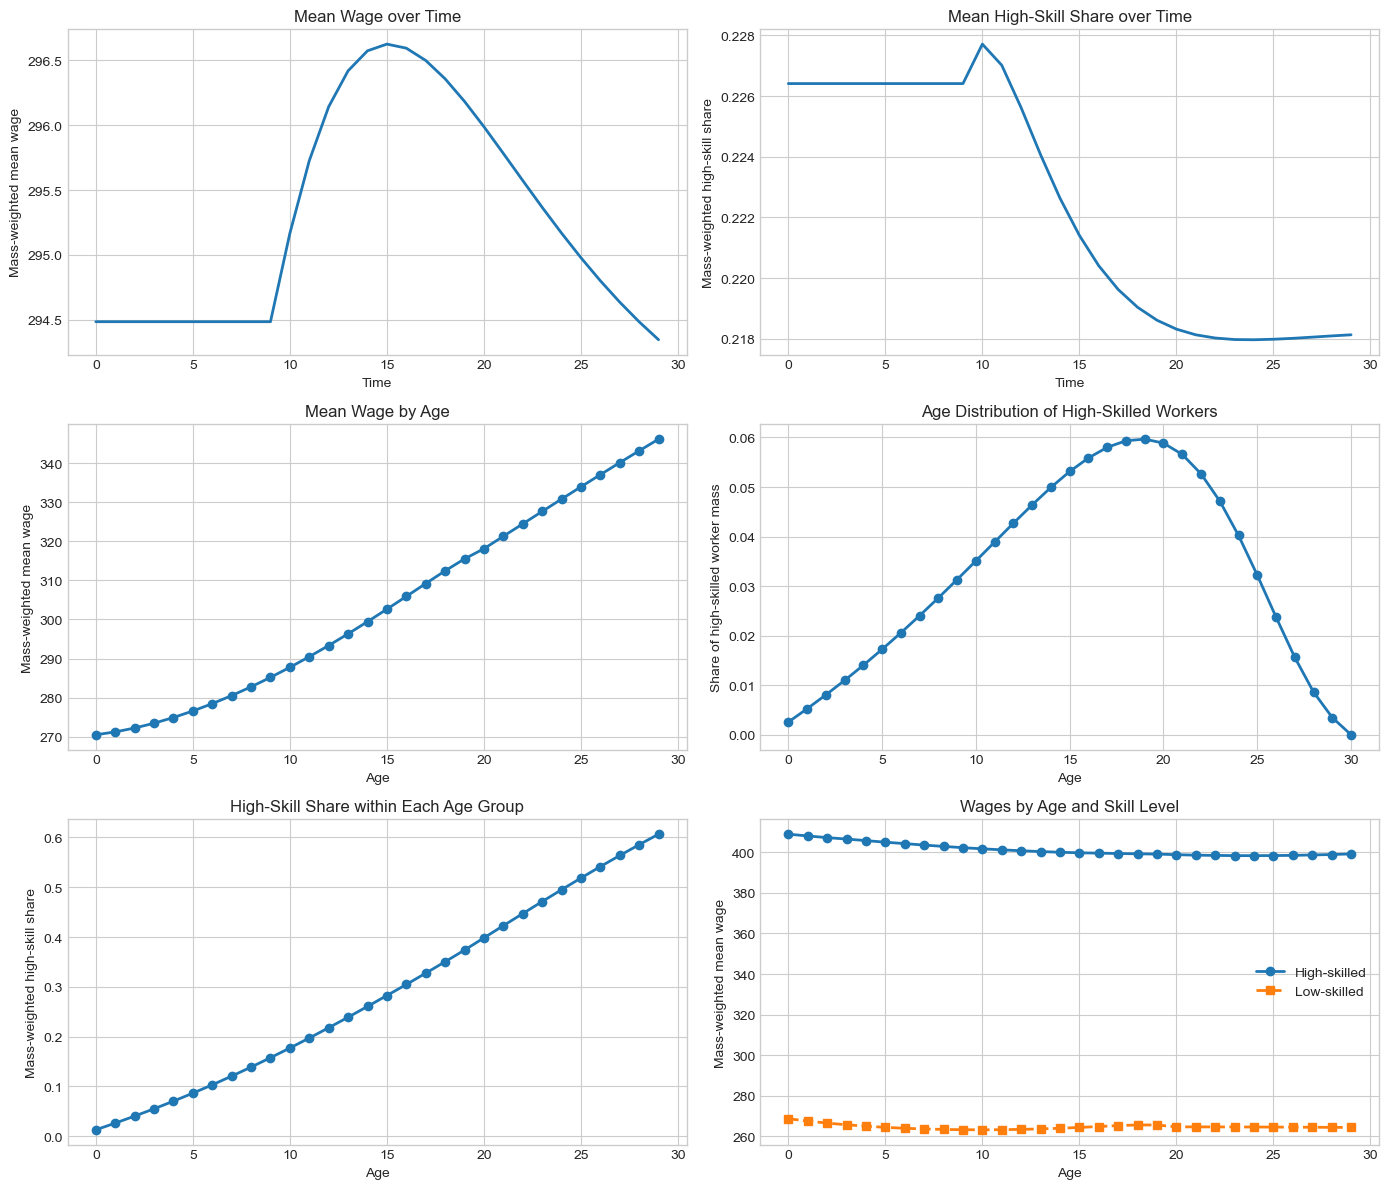

In [9]:
plot_model(model)

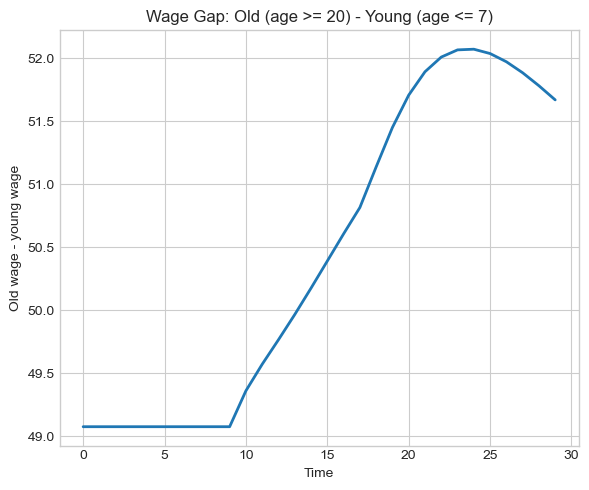

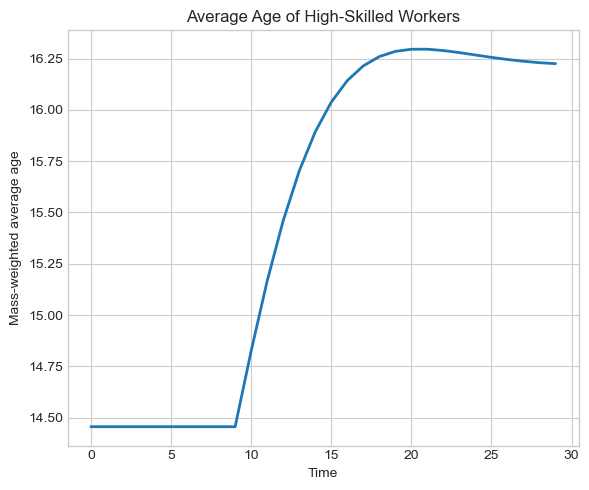

In [10]:
plot_wage_gap(model, young_max=7, old_min=20, x_size=6, y_size=5)
plot_mean_age_high_skill(model, x_size=6, y_size=5)

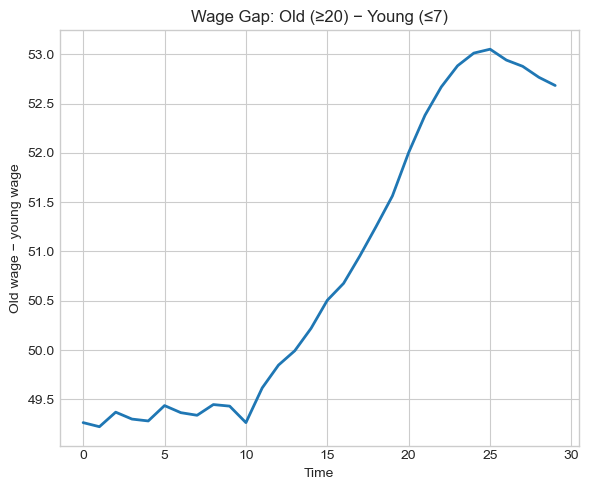

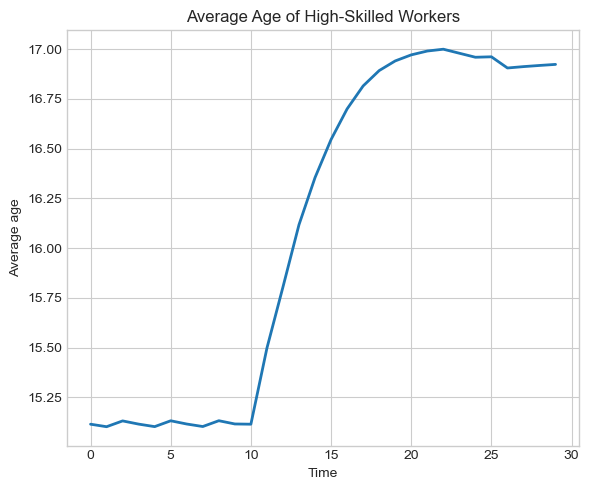